In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
et = pd.read_csv ('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/ethereum_price.csv',index_col=0,parse_dates=True)

In [ ]:
et.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2017-11-09,308.64,329.45,307.06,320.88,320.88,8.932500e+08
2017-11-10,320.67,324.72,294.54,299.25,299.25,8.859860e+08
2017-11-11,298.59,319.45,298.19,314.68,314.68,8.423010e+08
2017-11-12,314.69,319.15,298.51,307.91,307.91,1.613480e+09
2017-11-13,307.02,328.42,307.02,316.72,316.72,1.041890e+09


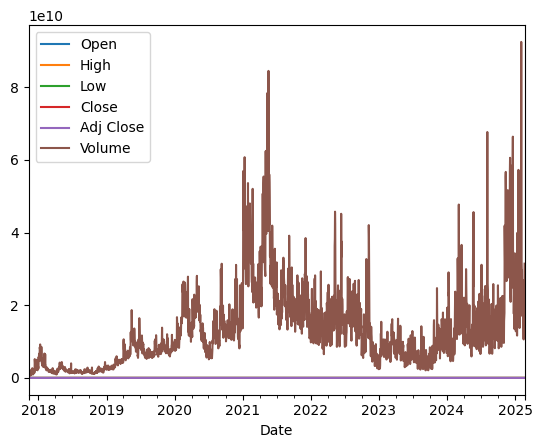

In [ ]:
et.plot();

In [ ]:
ap = pd.read_csv ('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/airline_passengers.csv',index_col=0,parse_dates=True)

In [ ]:
ap.head()

,Thousands of Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


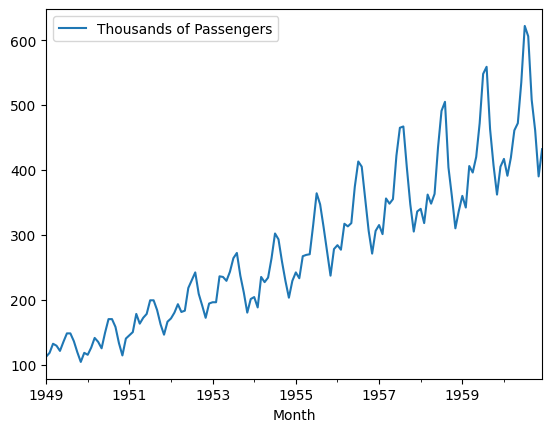

In [ ]:
ap.plot();

In [ ]:
#Q1
#What is the final expanded mean 'Close' price with day 30 window

et['Close'].expanding(min_periods=30).mean()
final_expanded_mean = et['Close'].expanding(min_periods=30).mean().iloc[-1]

print (final_expanded_mean)

1522.6199586776859


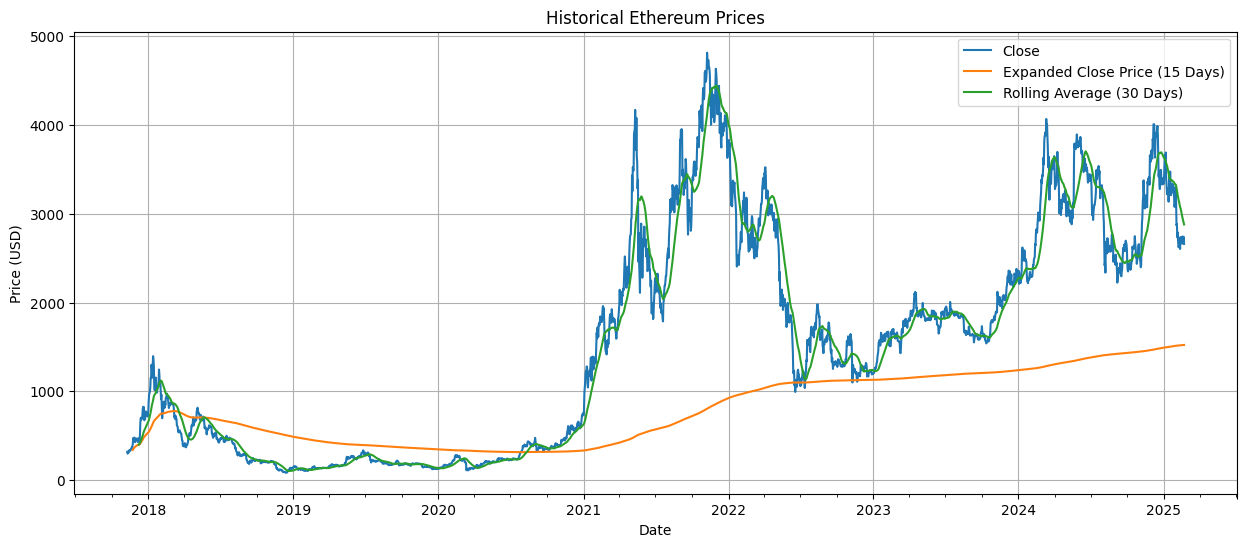

In [ ]:
#Q2 On Notebook
#Project the graph below with (15,6) size
et['Rolling Average (30 Days)'] = et['Close'].rolling(window=30).mean()
et['Expanded Close Price (15 Days)'] = et['Close'].expanding(min_periods=15).mean()

et[['Close', 'Expanded Close Price (15 Days)', 'Rolling Average (30 Days)']].plot(figsize=(15,6),grid=True).autoscale(axis='x',tight=False)
plt.title('Historical Ethereum Prices'), plt.xlabel('Date'), plt.ylabel('Price (USD)')
plt.show()

In [ ]:
#Q3
#Based on the graph Q2 above, what can you generalize  about Etheruem prices?

It's the ups and downs of the price of ethereum as time goes on, the ups and down as well don't have a consistency.

In [ ]:
#Q4
#What is the highest and lowest Etheruem 'Close' Prices from 2022 to 2024 only based on data?
et_prices = et[(et.index >= '2022-01-01') & (et.index <= '2024-12-31')]

highestClose = et_prices['Close'].max()
lowestClose = et_prices['Close'].min()
print("Highest Etheruem Price (2022-2024): ", highestClose, "Lowest Etheruem Price (2022-2024): ",lowestClose)


Highest Etheruem Price (2022-2024):  4066.45 Lowest Etheruem Price (2022-2024):  993.64


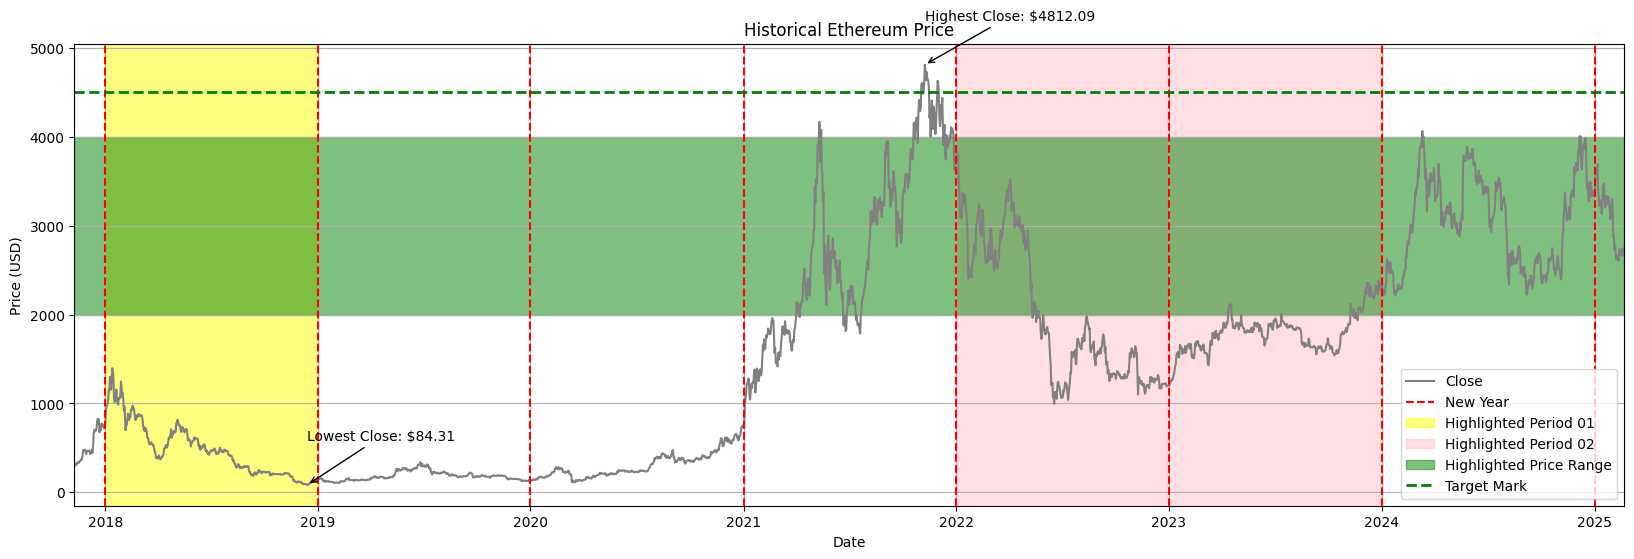

In [ ]:
#Q5 On Notebook
#Project the graph below with (20,6) size and 99% similarity, colors  should be similar but not exact
#Check the date formatting below

et.index = pd.to_datetime(et.index)

plt.figure(figsize=(20, 6))
plt.plot(et.index, et['Close'], color='grey', label='Close')

new_years = pd.date_range(start='2018-01-01', end='2025-01-01', freq='YS')
for date in new_years:
    plt.axvline(date, color='red', linestyle='dashed', label='New Year' if date == new_years[0] else "")

plt.axvspan(pd.Timestamp('2018-01-01'), pd.Timestamp('2019-01-01'), color='yellow', alpha=0.5, label='Highlighted Period 01')
plt.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2024-01-01'), color='pink', alpha=0.5, label='Highlighted Period 02')

plt.axhspan(2000, 4000, color='green', alpha=0.5, label='Highlighted Price Range')

plt.axhline(4500, color='green', linestyle='dashed', linewidth=2, label='Target Mark')

highest_close = et['Close'].max()
lowest_close = et['Close'].min()

highest_date = et[et['Close'] == highest_close].index[0]
lowest_date = et[et['Close'] == lowest_close].index[0]

plt.annotate(f'Highest Close: ${highest_close:.2f}', xy=(highest_date, highest_close),
             xytext=(highest_date, highest_close + 500), arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Lowest Close: ${lowest_close:.2f}', xy=(lowest_date, lowest_close),
             xytext=(lowest_date, lowest_close + 500), arrowprops=dict(arrowstyle='->'))

plt.title("Historical Ethereum Price"), plt.xlabel("Date"), plt.ylabel("Price (USD)")
plt.autoscale(axis='x',tight=True), plt.legend(), plt.grid(True)
plt.show()

<ipython-input-243-224bff10cd16>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  et_monthly = et['Close'].resample('M').mean()


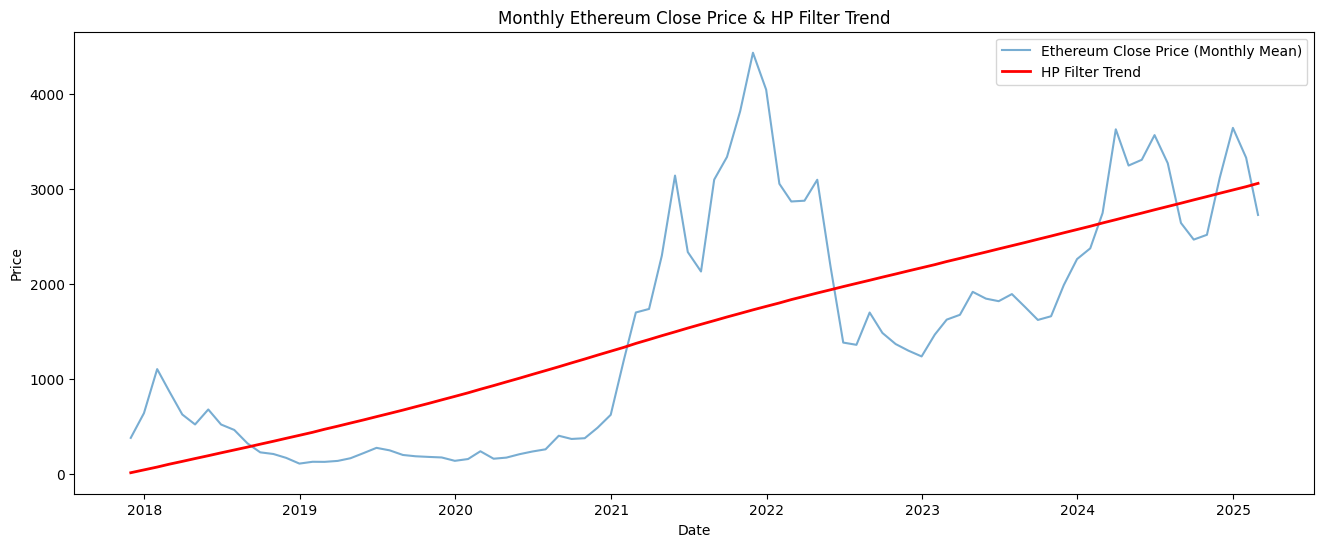

In [ ]:
#Q6
#Using HP-Filter resample to monthly (Month End) mean, what is the trend of Ethereum Close Pricing? (write your ansuer)
#Project the appropriate graph to support your answer (I will check this on your emailed link)
import statsmodels.api as sm
from statsmodels.tsa.filters.hp_filter import hpfilter

title = 'Monthly Ethereum Close Price & HP Filter Trend'
et_monthly = et['Close'].resample('M').mean()

cycle, trend = hpfilter(et_monthly, lamb=129600)

plt.figure(figsize=(16, 6))
plt.plot(et_monthly, label='Ethereum Close Price (Monthly Mean)', color='#1f77b4', alpha=0.6)
plt.plot(trend, label='HP Filter Trend', color='red', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(title)
plt.legend()
plt.show()

<ipython-input-244-f9f17197936b>:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  et_quarterly = et['Close'].resample('Q').mean()


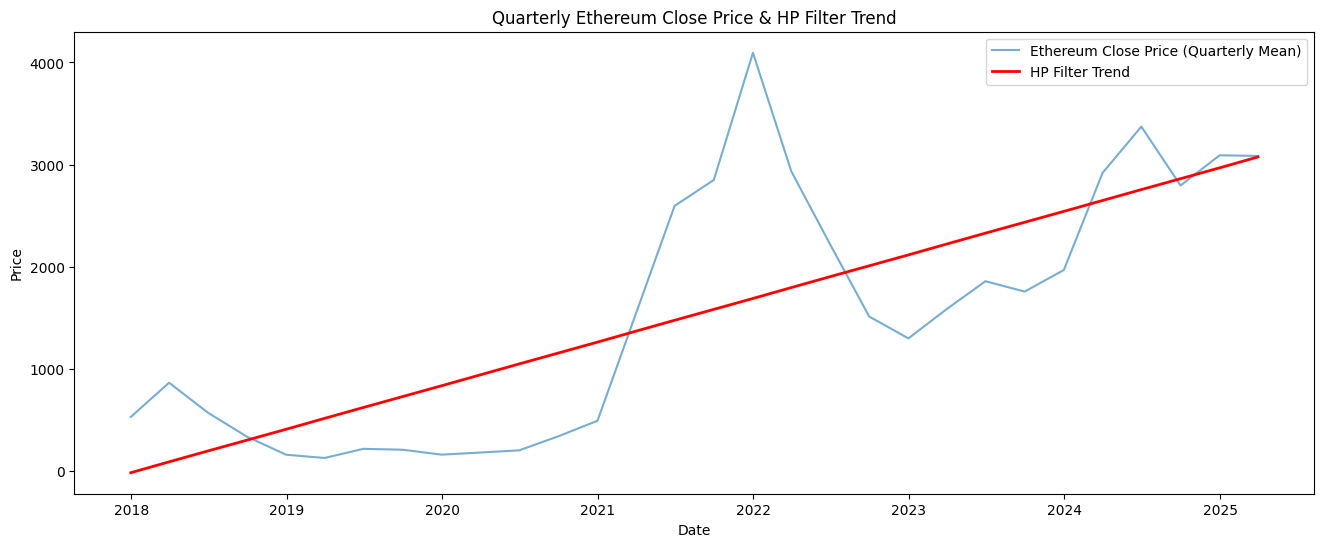

In [ ]:
#Q7
#Using HP-Filter resample to quarterly (Quarter End) mean, What is the trend of Ethereum Close Pricing?
#Project the appropriate graph to support your answer.
title = 'Quarterly Ethereum Close Price & HP Filter Trend'
et_quarterly = et['Close'].resample('Q').mean()

cycle, trend = hpfilter(et_quarterly, lamb=129600)

plt.figure(figsize=(16, 6))
plt.plot(et_quarterly, label='Ethereum Close Price (Quarterly Mean)', color='#1f77b4', alpha=0.6)
plt.plot(trend, label='HP Filter Trend', color='red', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(title)
plt.legend()
plt.show()

<ipython-input-245-d22e9a16e6f9>:6: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  ap_quarterly = ap['Thousands of Passengers'].resample('Q').mean()


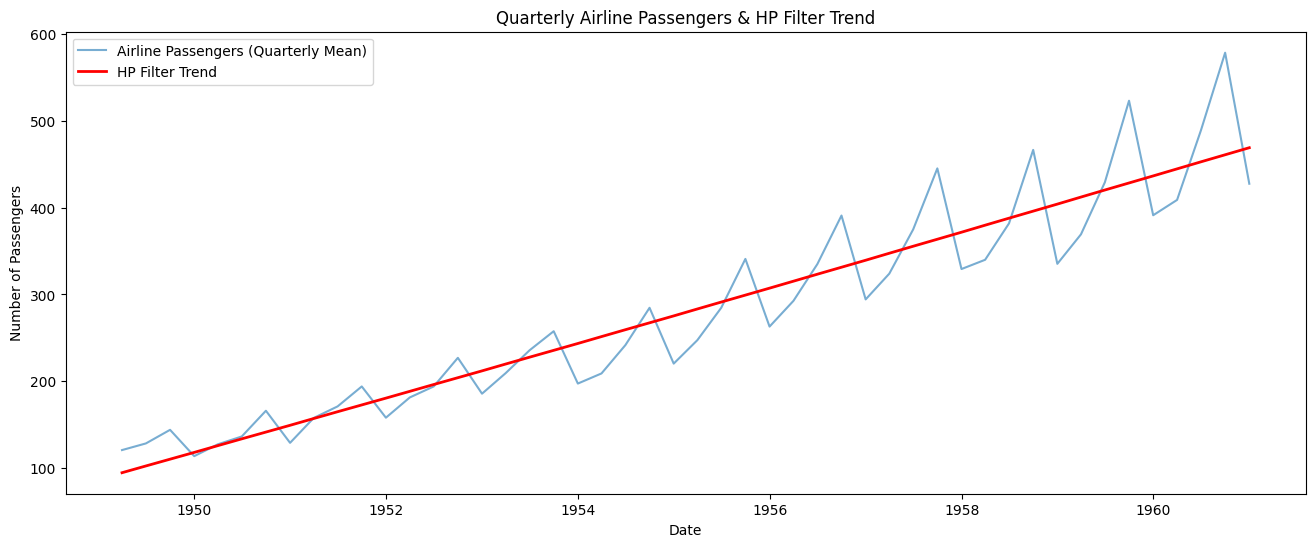

In [ ]:
#Q8
#Using HP-Filter resample to quarterly (Quarter End) mean, What is the trend of Airline Passengers?
#Project the appropriate graph to support your answer.

title = 'Quarterly Airline Passengers & HP Filter Trend'
ap_quarterly = ap['Thousands of Passengers'].resample('Q').mean()

cycle, trend = hpfilter(ap_quarterly, lamb=129600)

plt.figure(figsize=(16, 6))
plt.plot(ap_quarterly, label='Airline Passengers (Quarterly Mean)', color='#1f77b4', alpha=0.6)
plt.plot(trend, label='HP Filter Trend', color='red', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title(title)
plt.legend()
plt.show()

<ipython-input-246-a125864e66f5>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ap_monthly = ap['Thousands of Passengers'].resample('M').mean()


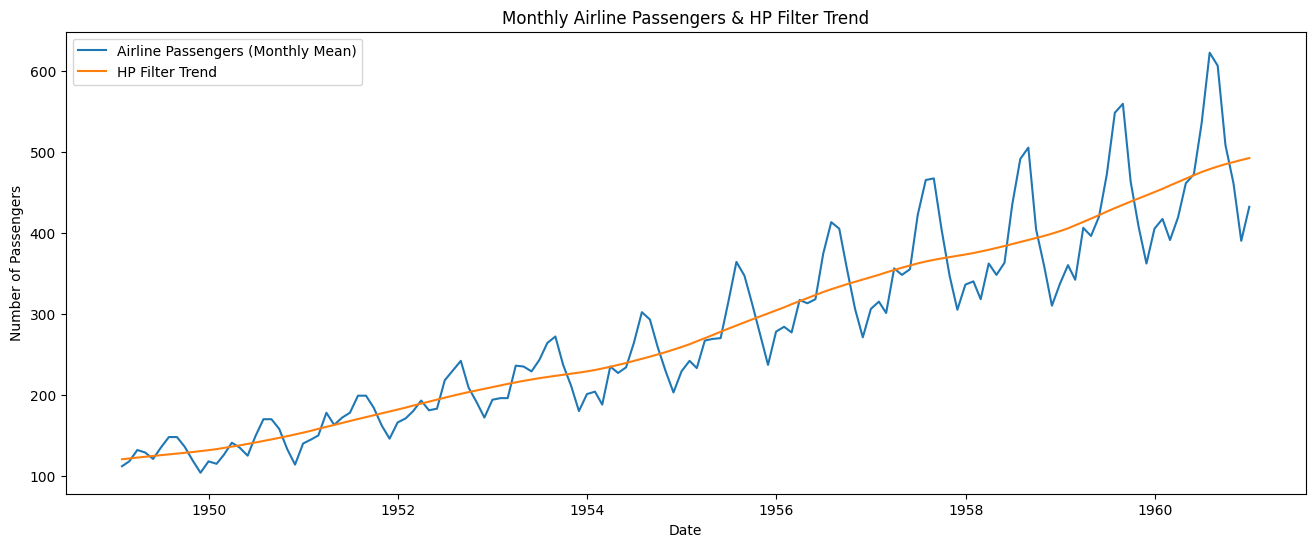

In [ ]:
#Q9
#Using HP-Filter resample to monthly (Month End) mean, what is the trend of Airline Passengers? (Write your answer)
#Project the appropriate graph to support your answer (I will check this on your emailed link)
# Resample to monthly (Month End) mean

ap_monthly = ap['Thousands of Passengers'].resample('M').mean()

cycle, trend = hpfilter(ap_monthly, lamb=1600)

plt.figure(figsize=(16, 6))
plt.plot(ap_monthly, label='Airline Passengers (Monthly Mean)')
plt.plot(trend, label='HP Filter Trend')
plt.xlabel('Date')
plt.ylabel('Number of Passengers')
plt.title('Monthly Airline Passengers & HP Filter Trend')
plt.legend()
plt.show()

<ipython-input-248-3b045355032f>:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  et_monthly = et['Close'].resample('M').mean()


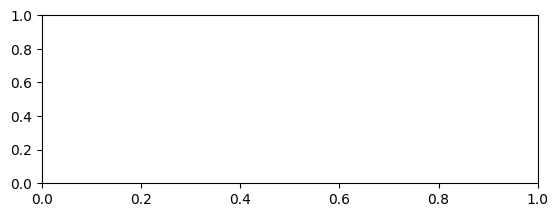

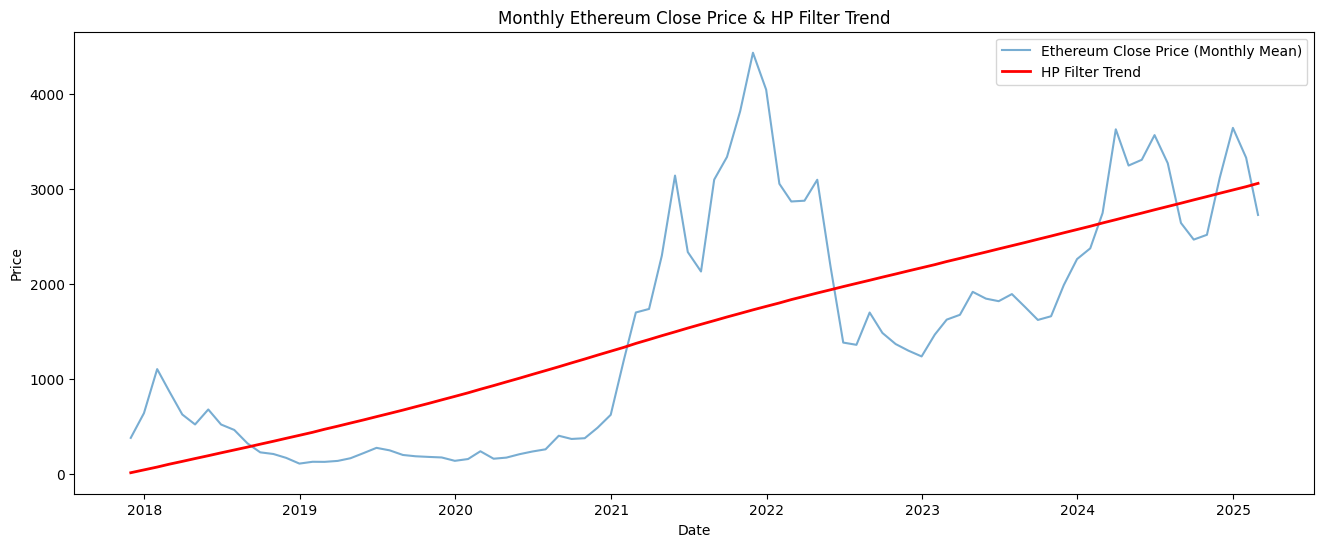

<ipython-input-248-3b045355032f>:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ap_monthly = ap['Thousands of Passengers'].resample('M').mean()


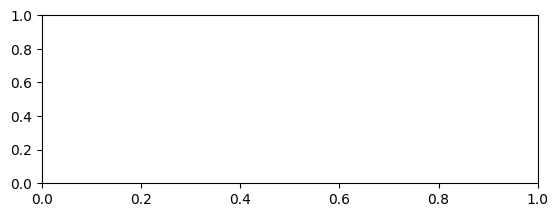

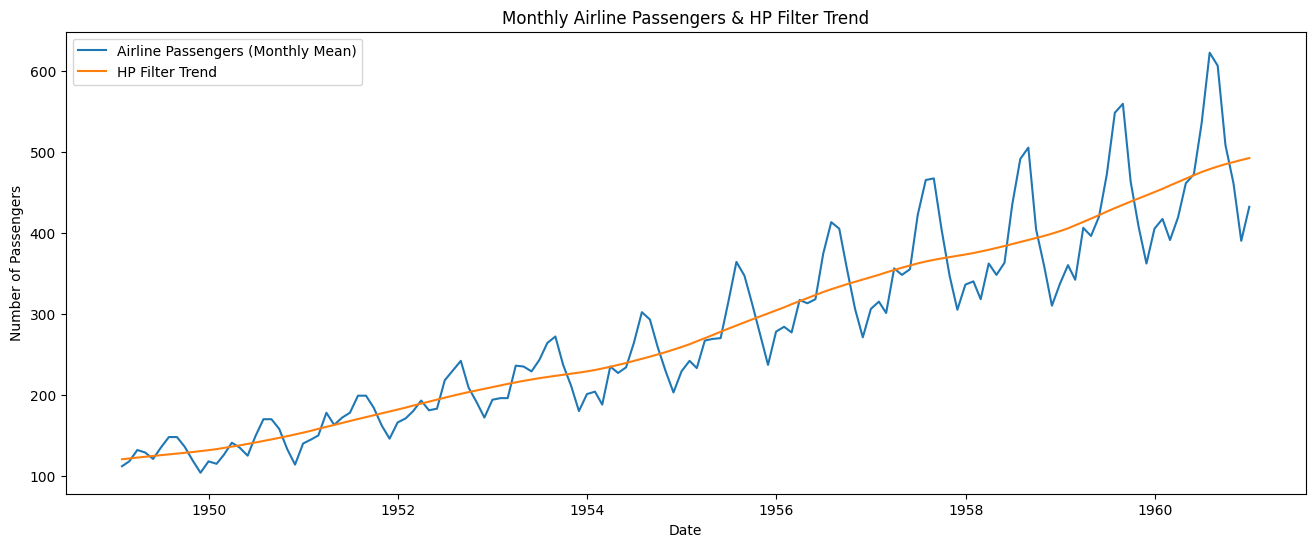

In [248]:
#Q10
# Using HP-Filter what can you infer about the cycles of Bitcoin Price and Airline Passengers, if resampled to monthly (Month end) mean?
#(write your answer)

et_monthly = et['Close'].resample('M').mean()
ap_monthly = ap['Thousands of Passengers'].resample('M').mean()

cycle_et, trend_et = hpfilter(et_monthly, lamb=129600)
cycle_ap, trend_ap = hpfilter(ap_monthly, lamb=1600)

fig, ax = plt.subplots(2, 1, figsize=(16, 12))

ax[0].plot(et_monthly, label='Ethereum Close Price (Monthly Mean)', color='#1f77b4', alpha=0.6)
ax[0].plot(trend_et, label='HP Filter Trend', color='red', linewidth=2)
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Price')
ax[0].set_title('Monthly Ethereum Close Price & HP Filter Trend')
ax[0].legend()

ax[1].plot(ap_monthly, label='Airline Passengers (Monthly Mean)', color='blue', alpha=0.6)
ax[1].plot(trend_ap, label='HP Filter Trend', color='red', linewidth=2)
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Number of Passengers')
ax[1].set_title('Monthly Airline Passengers & HP Filter Trend')
ax[1].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()